# Tree-Based Regression Methods for 3D Sinusoidal Data
## An Applied Machine Learning
## by Sean Fletcher

## Overview

In this project, I fit a `Gradient-Boosted Regression Tree`, a `Random Forest`, and a `Decision Tree` to a noisy 3D sinusoidal data set.  I manually swept the hyperparameter space to hone in on the optimal hyperparameter values. I then retrain the model with the optimal hyperparameters.  

Next, I performed several grid searches to compare my "optimal" hyperparameter values with those computed from the grid search.

Each model prediction was visualized for the optimal `Gradient-Boosted Regression Tree`, `Random Forest`, and `Decision Tree` models determined by the grid searches.  

Finally, I found the generalization error on the test set for the three models.

## Preliminaries

Imported necessary packages.

In [4]:
# Common imports
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
import numpy as np
import pandas as pd
%matplotlib inline
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
import os

# Directories to save figures
PROJECT_ROOT_DIR = "."
FOLDER = "figures"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, FOLDER)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

## Plotting

Set up the two plots (__plot3Ddata__ and __plotscatter3Ddata__) with four subplots each. 

In [17]:
def plot3Ddata(data_df):
    
    from mpl_toolkits.mplot3d import Axes3D
    x = data_df['x']
    y = data_df['y']
    z = data_df['z']
    
    fig = plt.figure(figsize=[18, 10])

    font = {'family': 'serif',
            'color':  'darkred',
            'weight': 'normal',
            'size': 16,
            }

    #===============
    # First subplot
    #===============
    ax = fig.add_subplot(2, 2, 1, projection='3d')

    ax.view_init(0, 89)

    ax.scatter3D(x, y, z);

    ax.set_xlabel('x',fontdict=font)
    ax.set_ylabel('y',fontdict=font)
    ax.set_zlabel('z',fontdict=font)
    ax.set_xticks(range(0,16,2))
    ax.set_yticks(range(-6,8,2))
    ax.set_zticks(range(0,10,2))

 
    #===============
    # Second subplot
    #===============

    # set up the axes for the first plot
    ax = fig.add_subplot(2, 2, 2, projection='3d')
    ax.view_init(45, 0)

    ax.scatter3D(x, y, z);

    ax.set_xlabel('x',fontdict=font)
    ax.set_ylabel('y',fontdict=font)
    ax.set_zlabel('z',fontdict=font)
    ax.set_xticks(range(0,16,2))
    ax.set_yticks(range(-6,8,2))
    ax.set_zticks(range(0,10,2))


    #===============
    # Third subplot
    #===============

    # set up the axes for the first plot
    ax = fig.add_subplot(2, 2, 3, projection='3d')
    ax.view_init(45, 45)

    ax.scatter3D(x, y, z);

    ax.set_xlabel('x',fontdict=font)
    ax.set_ylabel('y',fontdict=font)
    ax.set_zlabel('z',fontdict=font)
    ax.set_xticks(range(0,16,2))
    ax.set_yticks(range(-6,8,2))
    ax.set_zticks(range(0,10,2))


    #===============
    # Fourth subplot
    #===============

    # set up the axes for the first plot
    ax = fig.add_subplot(2, 2, 4, projection='3d')
    ax.view_init(25, 30)

    ax.scatter3D(x, y, z);

    ax.set_xlabel('x',fontdict=font)
    ax.set_ylabel('y',fontdict=font)
    ax.set_zlabel('z',fontdict=font)
    ax.set_xticks(range(0,16,2))
    ax.set_yticks(range(-6,8,2))
    ax.set_zticks(range(0,10,2))


    plt.tight_layout(pad=0.5, w_pad=0.5, h_pad=0.5)  
    save_fig("Plot 1")
    plt.show()

In [19]:
def plotscatter3Ddata(fit_x, fit_y, fit_z, scat_x, scat_y, scat_z):
    
    fig = plt.figure(figsize=[18, 10])

    font = {'family': 'serif',
            'color':  'darkred',
            'weight': 'normal',
            'size': 16,
            }
 
    #===============
    # First subplot
    #===============
    ax = fig.add_subplot(2, 2, 1, projection='3d')

    ax.view_init(0, 89)

    ax.scatter3D(scat_x, scat_y, scat_z);
    ax.plot3D(fit_x, fit_y, fit_z, '-k');

    ax.set_xlabel('x',fontdict=font)
    ax.set_ylabel('y',fontdict=font)
    ax.set_zlabel('z',fontdict=font)
    ax.set_xticks(range(0,16,2))
    ax.set_yticks(range(-6,8,2))
    ax.set_zticks(range(0,10,2))

 
    #===============
    # Second subplot
    #===============

    # set up the axes for the first plot
    ax = fig.add_subplot(2, 2, 2, projection='3d')
    ax.view_init(45, 0)

    ax.scatter3D(scat_x, scat_y, scat_z);
    ax.plot3D(fit_x, fit_y, fit_z, '-k');

    ax.set_xlabel('x',fontdict=font)
    ax.set_ylabel('y',fontdict=font)
    ax.set_zlabel('z',fontdict=font)
    ax.set_xticks(range(0,16,2))
    ax.set_yticks(range(-6,8,2))
    ax.set_zticks(range(0,10,2))


    #===============
    # Third subplot
    #===============

    # set up the axes for the first plot
    ax = fig.add_subplot(2, 2, 3, projection='3d')
    ax.view_init(45, 45)

    ax.scatter3D(scat_x, scat_y, scat_z);
    ax.plot3D(fit_x, fit_y, fit_z, '-k');

    ax.set_xlabel('x',fontdict=font)
    ax.set_ylabel('y',fontdict=font)
    ax.set_zlabel('z',fontdict=font)
    ax.set_xticks(range(0,16,2))
    ax.set_yticks(range(-6,8,2))
    ax.set_zticks(range(0,10,2))


    #===============
    # Fourth subplot
    #===============

    # set up the axes for the first plot
    ax = fig.add_subplot(2, 2, 4, projection='3d')
    ax.view_init(25, 30)

    ax.scatter3D(scat_x, scat_y, scat_z);
    ax.plot3D(fit_x, fit_y, fit_z, '-k');

    ax.set_xlabel('x',fontdict=font)
    ax.set_ylabel('y',fontdict=font)
    ax.set_zlabel('z',fontdict=font)
    ax.set_xticks(range(0,16,2))
    ax.set_yticks(range(-6,8,2))
    ax.set_zticks(range(0,10,2))


    plt.tight_layout(pad=0.5, w_pad=0.5, h_pad=0.5)  
    save_fig("Plot 1")
    plt.show()

# Import and Split Data

Imported the data from the file called `3DSinusoidal.csv`.  Name the returned DataFrame `data`. 

Called train_test_split() with a `test_size` of 20%.  `x` and `y` is the feature data and `z` is the response data. Saved the output into `X_train`, `X_test`, `z_train`, and `z_test`, respectively.  

Specified the `random_state` parameter to be `42` throughout the entire note book.

In [22]:
from sklearn.model_selection import train_test_split
data = pd.read_csv("3DSinusoidal.csv")
data = data.sort_values(by=['x']).reset_index(drop=True)
X = data.iloc[:,[0,1]]
z = data.z

X_train, X_test, z_train, z_test = train_test_split(X, z, test_size=0.20, random_state=42)

# Reshape X Data and Make NumPy Arrays
X_train = np.array(X_train)
X_test = np.array(X_test)
z_train = np.array(z_train)
z_test = np.array(z_test)

#train_data = pd.DataFrame(X_train, z_train).reset_index()
#train_data = train_data.set_axis(['x','y','z'],axis=1)
#train_data = train_data.sort_values(by='x')
#train_data = train_data.reset_index(drop=True)

# Plot Data

Plotted the data using __plot3Ddata__ defined above.

Saving figure Plot 1


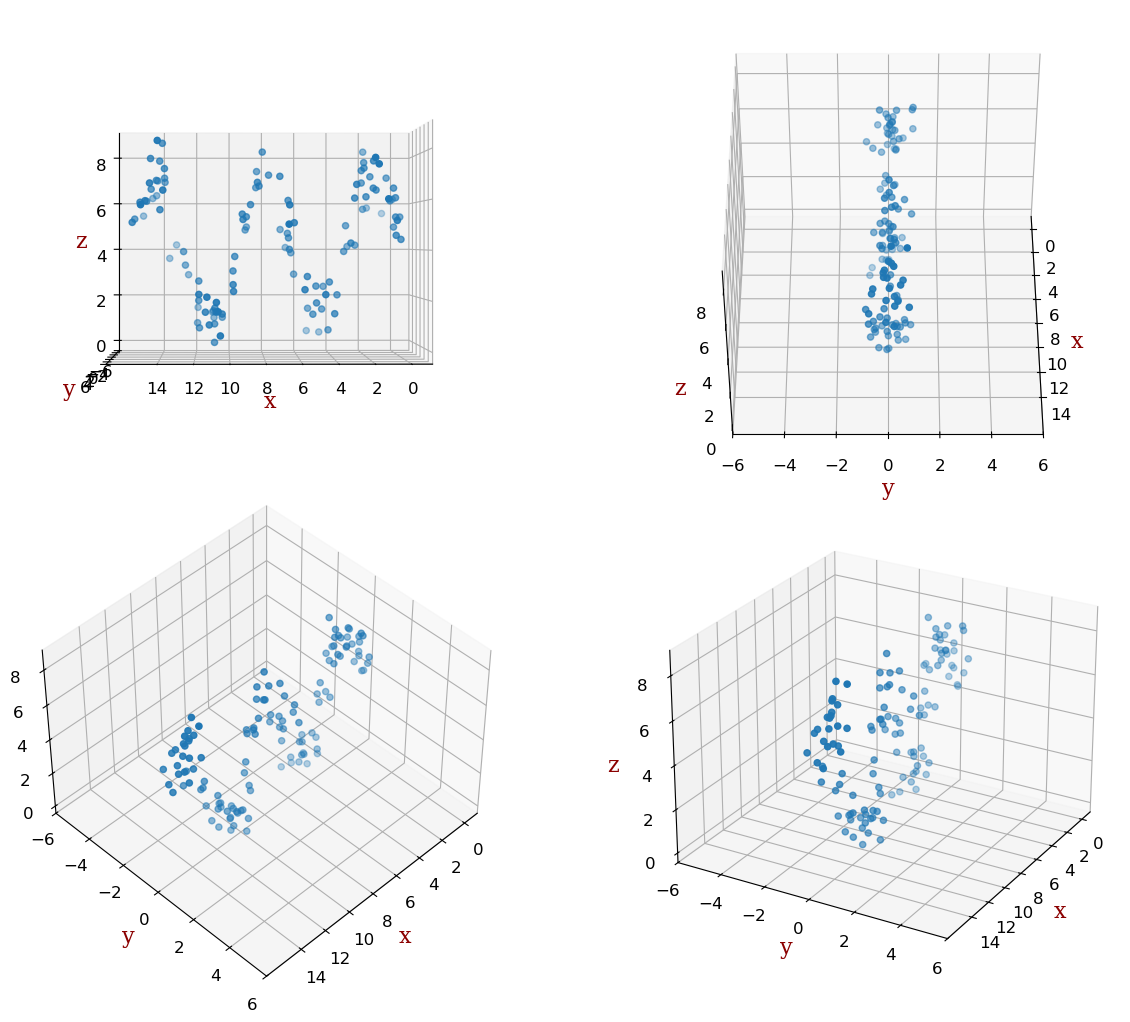

In [25]:
train_df = data
plot3Ddata(train_df)


## A Quick Note

In the following sections you will be asked to plot the training data along with the model's predictions for that data superimposed on it.  You must write a function called `plotscatter3Ddata(fit_x, fit_y, fit_z, scat_x, scat_y, scat_z)` that will plot this figure.  The function accepts six parameters as input, shown in the function signature.  All six input parameters must be NumPy arrays. The Numpy arrays called fit_x and fit_y represent the x and y coordinates from the training data and fit_z represents the model predictions from those coordinates (i.e. the prediction curve). The three Numpy arrays called `scat_x, scat_y,` and  `scat_z` represent the x, y, and z coordinates of the training data.   

You must place the definition of the `plotscatter3Ddata(fit_x, fit_y, fit_z, scat_x, scat_y, scat_z)` function in the existing code cell of the above __Preliminaries__ section. (The function header is already there - you must complete the function definition.)

You will use the `plotscatter3Ddata()` function in each of the below __Plot Model Predictions for Training Set__ portion of the three __Explore 3D Data__ sections, as well as the __Visualize Optimal Model Predictions__ section.

___Important: Below, you will be asked to plot the model's prediction curve along with the training data.  Even if you correctly train the model, you may find that your trendline is very ugly when you first plot it.  If this happens to you, try plotting the model's predictions using a scatter plot rather than a connected line plot.  You should be able to infer the problem and solution with the trendline from examining this new scatter plot of the model's predictions. All of your plots, however, should be connected line plots when submitted. Please refer to the FAQ document for more clarity.___

Note: You must use the supplied data and not np.linspace() to create the prediction curve.

# GradientBoostingRegressor

Fitted a `GradientBoostingRegressor` model to this data with manually assigned values for the following hyperparameters:
 - `learning_rate = (.001, .01, .05, .1, .5)`
 - `max_depth = (1, 2, 3, 4, 5) `
 - `n_estimators = (50, 200, 500, 1000, 10000)`
 - `random_state = 42`

Initial "best values" found:
 - `learning_rate = .1`
 - `max_depth = 3`
 - `n_estimators = 75`
 - `random_state = 42`

In [28]:
from sklearn.ensemble import GradientBoostingRegressor 

gb_reg = GradientBoostingRegressor(random_state = 42, learning_rate =.1, max_depth = 4, n_estimators = 75)
gb_reg.fit(X_train, z_train)


GradientBoostingRegressor(max_depth=4, n_estimators=75, random_state=42)

### Model Predictions for Training Set

Used the `plotscatter3Ddata(fit_x, fit_y, fit_z, scat_x, scat_y, scat_z)` function to plot the data and the prediction curve.

Saving figure Plot 1


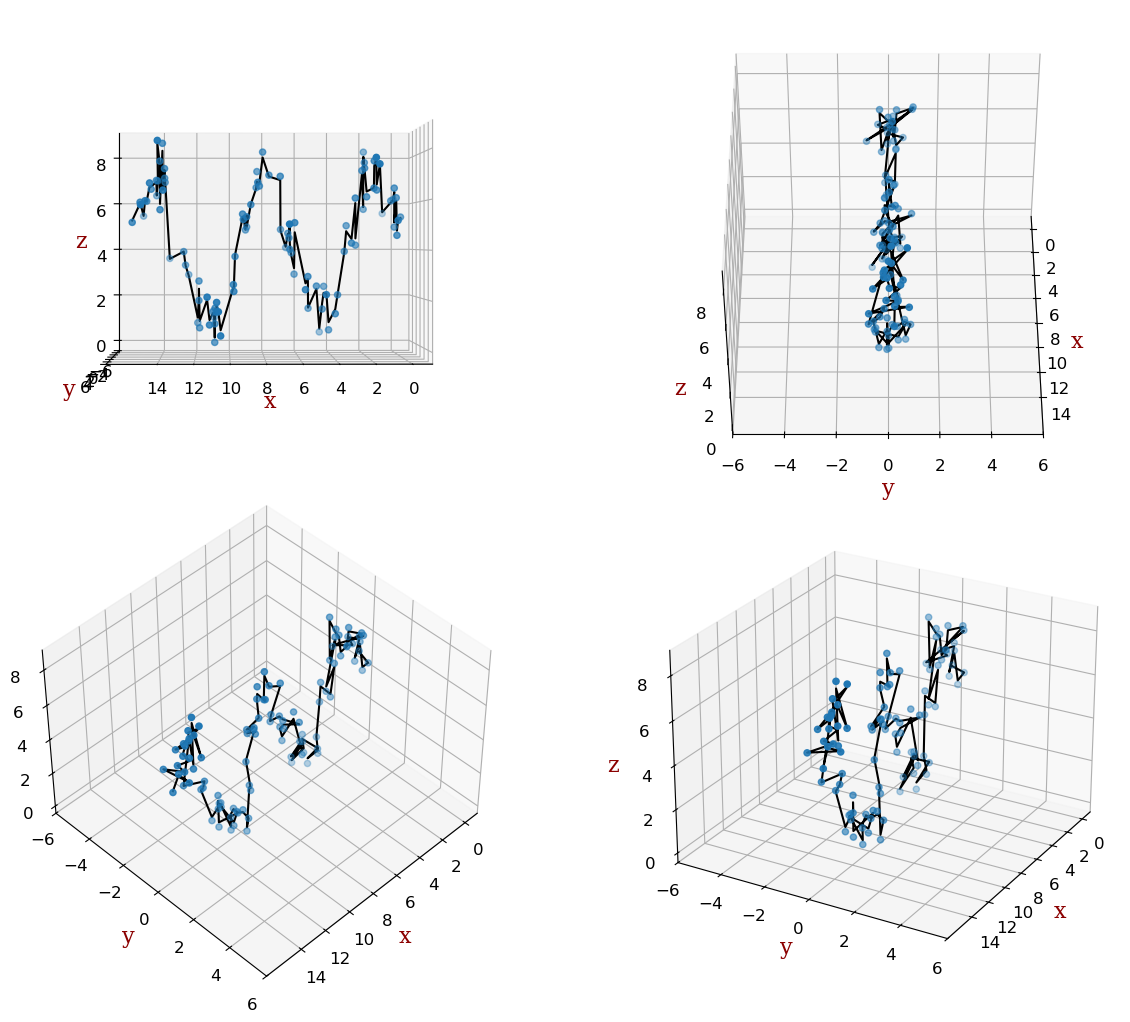

In [31]:
gb_fit_z = gb_reg.predict(X_train)

X_train_sort = X_train[X_train[:,0].argsort()]
gb_fit_z = gb_fit_z[X_train[:,0].argsort()]
plotscatter3Ddata(X_train_sort[:,0], X_train_sort[:,1], gb_fit_z, X_train[:,0], X_train[:,1], z_train)

# RandomForestRegressor

Fitted a `RandomForestRegressor` model to this data with manually assigned values for the following hyperparameters:
 - `min_samples_split = (2,4,5,6,8)`
 - `max_depth = (2,3,4,5,6)`
 - `n_estimators = 500, 1000, 5000, 10000`
 - `random_state = 42`

Initial "best values" found:
 - `min_samples_split = 5`
 - `max_depth = 5`
 - `n_estimators = 5000`
 - `random_state = 42`

In [34]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(random_state = 42, min_samples_split = 5, max_depth = 5, n_estimators = 5000)
rf_reg.fit(X_train, z_train)

RandomForestRegressor(max_depth=5, min_samples_split=5, n_estimators=5000,
                      random_state=42)

### Plot Model Predictions for Training Set

Use the `plotscatter3Ddata(fit_x, fit_y, fit_z, scat_x, scat_y, scat_z)` function to plot the data and the prediction curve.

Saving figure Plot 1


C:\Users\swf\AppData\Local\Temp\ipykernel_4212\143566409.py:23: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


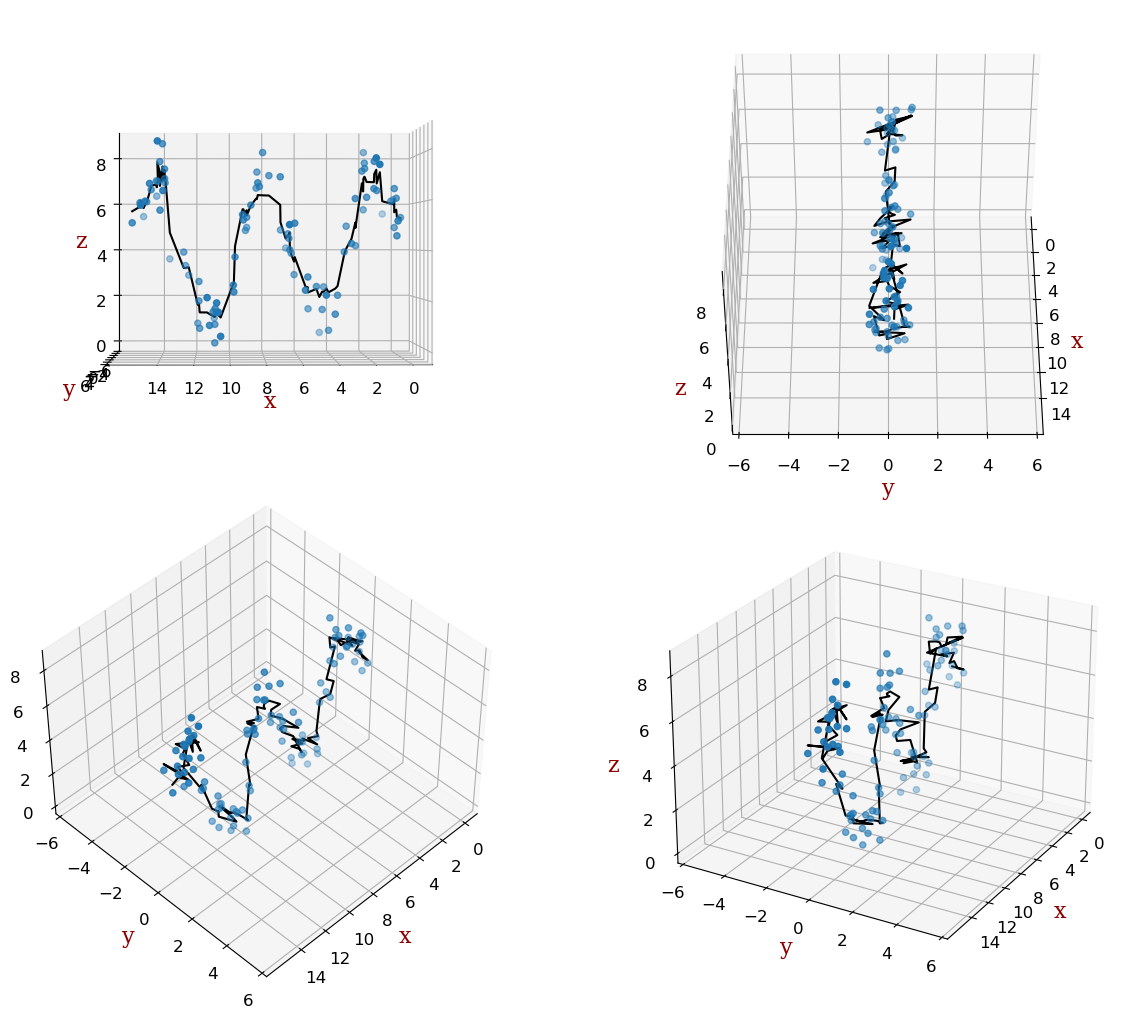

In [55]:
rf_fit_z = rf_reg.predict(X_train)
X_train_sort = X_train[X_train[:,0].argsort()]
rf_fit_z = rf_fit_z[X_train[:,0].argsort()]
plotscatter3Ddata(X_train_sort[:,0], X_train_sort[:,1], rf_fit_z, X_train[:,0], X_train[:,1], z_train)

# DecisionTreeRegressor

Fitted a `DecisionTreeRegressor` model to this data with manually assigned values for the following hyperparameters:
 - `splitter = (best, random)`
 - `max_depth = (2,3,5,8, 10)`
 - `min_samples_split = (2, 5, 15,20,25)`
 - `random_state = 42`

Initial "best values" found:
 - `splitter = <value>`
 - `max_depth = <value>`
 - `min_samples_split = <value>`
 - `random_state = 42`

In [48]:
from sklearn.tree import DecisionTreeRegressor

dt_reg = DecisionTreeRegressor(random_state = 42, splitter ='best', max_depth = 10, min_samples_split = 15)
dt_reg.fit(X_train, z_train)

DecisionTreeRegressor(max_depth=10, min_samples_split=15, random_state=42)

### Model Predictions for Training Set

Used the `plotscatter3Ddata(fit_x, fit_y, fit_z, scat_x, scat_y, scat_z)` function to plot the data and the prediction curve.

Saving figure Plot 1


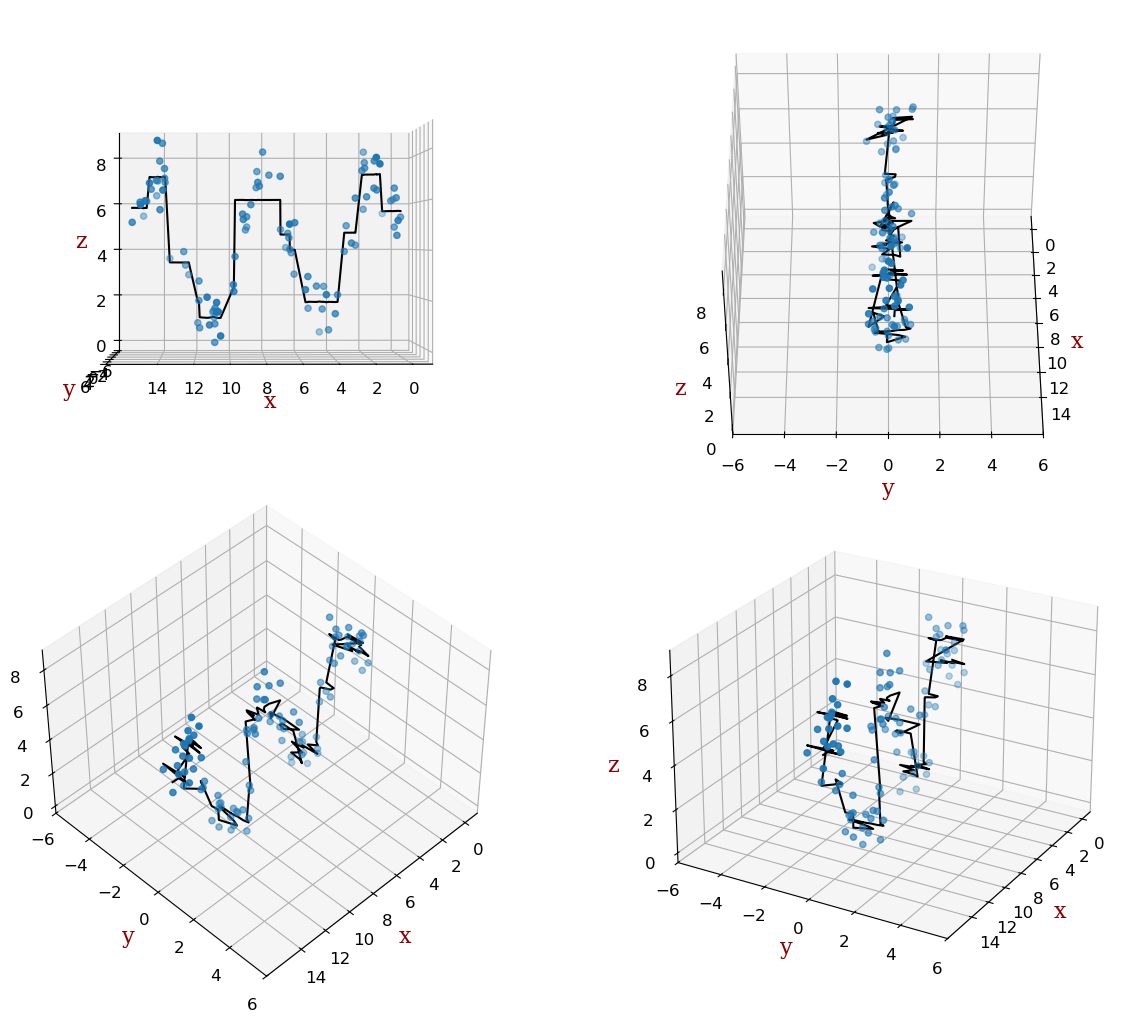

In [51]:
dt_fit_z = dt_reg.predict(X_train)
X_train_sort = X_train[X_train[:,0].argsort()]
dt_fit_z = dt_fit_z[X_train[:,0].argsort()]
plotscatter3Ddata(X_train_sort[:,0], X_train_sort[:,1], dt_fit_z, X_train[:,0], X_train[:,1], z_train)

# Grid Searches

Performed a series of grid searches, which yielded the optimal hyperparamter values for each of the three model types.  I then compared the values computed by the grid search with the values I manually found earlier.  

Each grid searh was performed with a course-grained grid search, with a very broad range of values first.  Each subsequent search was performed using a tighter range of values centered on those identified in the previous grid search.  This was repeated for several rounds on each grid search.

Grid searches were conducted on the following hyperparameters:

   GradientBoostingRegressor:
    
     - `max_depth = <value>`
     - `n_estimators = <value>`
     - `learning_rate = <value>`

   RandomForestRegressor:
    
     - `max_depth = <value>`
     - `n_estimators = <value>`
     - `min_samples_split = <value>`

   DecisionTreeRegressor:
    
     - `splitter = <value>`
     - `max_depth = <value>`
     - `min_samples_split = <value>`
     
     
Note: The `learning rate` was rounded to two decimals the number of cross-folds was specified as `cv=3`.


In [54]:
from sklearn.model_selection import GridSearchCV

# -----
# Coarse-Grained GradientBoostingRegressor GridSearch
# -----

coarse_gb_param_grid = {'max_depth': [2,3,4,5,8,16,32], 'n_estimators': list(range(2, 1000, 100)), 'learning_rate': [.01, .1, .25, .5, .75, 1]}
coarse_gb_grid_search_cv = GridSearchCV(GradientBoostingRegressor(random_state = 42), coarse_gb_param_grid, verbose = 1, cv = 3)
coarse_gb_grid_search_cv.fit(X_train, z_train)
print("The best parameters are: ", coarse_gb_grid_search_cv.best_params_)

Fitting 3 folds for each of 420 candidates, totalling 1260 fits
The best parameters are:  {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 102}


C:\Users\swf\AppData\Local\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


In [55]:
# -----
# Refined GradientBoostingRegressor GridSearch
# -----

refined_gb_param_grid = {'max_depth': [1,2,3,4,5], 'n_estimators': [50, 75, 102, 125, 150], 'learning_rate': [.005, .01, .1, .25, .5]}
refined_gb_grid_search_cv = GridSearchCV(GradientBoostingRegressor(random_state = 42), refined_gb_param_grid, verbose = 1, cv = 3)
refined_gb_grid_search_cv.fit(X_train, z_train)
print("The best parameters are: ",refined_gb_grid_search_cv.best_params_)

Fitting 3 folds for each of 125 candidates, totalling 375 fits
The best parameters are:  {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 102}


In [56]:
# -----
# Final GradientBoostingRegressor GridSearch
# -----

final_gb_param_grid = {'max_depth': [1,2,3,4], 'n_estimators': [100, 101, 102, 103, 104], 'learning_rate': [.05, .075, .1, .125, .15]}
final_gb_grid_search_cv = GridSearchCV(GradientBoostingRegressor(random_state = 42), final_gb_param_grid, verbose = 1, cv = 3)
final_gb_grid_search_cv.fit(X_train, z_train)
print("The best parameters are: ", final_gb_grid_search_cv.best_params_)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
The best parameters are:  {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 104}


On this dataset, the optimal model parameters for the `GradientBoostingRegressor` class was:

- `learning_rate = 0.1`
- `max_depth = 2`
- `n_estimators = 104`

In [58]:
# -----
# Coarse-Grained RandomForestRegressor GridSearch
# -----

coarse_rf_param_grid = {'max_depth': [2,3,4,5,8,16,32], 'n_estimators': list(range(2, 1000, 100)), 'min_samples_split': [2,3,4,5,8,12,16,20]}
coarse_rf_grid_search_cv = GridSearchCV(RandomForestRegressor(random_state = 42), coarse_rf_param_grid, verbose = 1, cv = 3)
coarse_rf_grid_search_cv.fit(X_train, z_train)
print("The best parameters are: ", coarse_rf_grid_search_cv.best_params_)

Fitting 3 folds for each of 560 candidates, totalling 1680 fits
The best parameters are:  {'max_depth': 16, 'min_samples_split': 3, 'n_estimators': 202}


C:\Users\swf\AppData\Local\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


In [59]:
# -----
# Refined RandomForestRegressor GridSearch
# -----

refined_rf_param_grid = {'max_depth': [12,14,16,18,20], 'n_estimators': list([150, 175, 202, 225, 250]), 'min_samples_split': [1,2,3,4,5]}
refined_rf_grid_search_cv = GridSearchCV(RandomForestRegressor(random_state = 42), refined_rf_param_grid, verbose = 1, cv = 3)
refined_rf_grid_search_cv.fit(X_train, z_train)
print("The best parameters are: ", refined_rf_grid_search_cv.best_params_)

Fitting 3 folds for each of 125 candidates, totalling 375 fits
The best parameters are:  {'max_depth': 12, 'min_samples_split': 3, 'n_estimators': 150}


C:\Users\swf\AppData\Local\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
75 fits failed out of a total of 375.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
75 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\swf\AppData\Local\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\swf\AppData\Local\anaconda3\Lib\site-packages\sklearn\base.py", line 1466, in wrapper
    estimator._validate_params()
  File "C:\Users\swf\AppData\Local\anaconda3\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraints(
  

In [60]:
# -----
# Final RandomForestRegressor GridSearch
# -----

final_rf_param_grid = {'max_depth': [10,11,12,13,14], 'n_estimators': [148,149,150,150,152], 'min_samples_split': [1,2,3,4,5]}
final_rf_grid_search_cv = GridSearchCV(RandomForestRegressor(random_state = 42), final_rf_param_grid, verbose = 1, cv = 3)
final_rf_grid_search_cv.fit(X_train, z_train)
print("The best parameters are: ", final_rf_grid_search_cv.best_params_)

Fitting 3 folds for each of 125 candidates, totalling 375 fits
The best parameters are:  {'max_depth': 11, 'min_samples_split': 3, 'n_estimators': 150}


C:\Users\swf\AppData\Local\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
75 fits failed out of a total of 375.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
75 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\swf\AppData\Local\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\swf\AppData\Local\anaconda3\Lib\site-packages\sklearn\base.py", line 1466, in wrapper
    estimator._validate_params()
  File "C:\Users\swf\AppData\Local\anaconda3\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraints(
  

On this dataset, the optimal model parameters for the `RandomForestRegressor` class was:

- `max_depth = 11`
- `n_estimators = 150`
- `min_samples_split = 3`

In [62]:
# -----
# Coarse-Grained DecisionTreeRegressor GridSearch
# -----

course_dt_param_grid = {'max_depth': [2,3,4,5,8,16,32], 'splitter': ['best', 'random'], 'min_samples_split': [2,3,4,5,8,12,16,20]}
course_dt_grid_search_cv = GridSearchCV(DecisionTreeRegressor(random_state = 42), course_dt_param_grid, verbose = 1, cv = 3)
course_dt_grid_search_cv.fit(X_train, z_train)
print("The best parameters are: ", course_dt_grid_search_cv.best_params_)

Fitting 3 folds for each of 112 candidates, totalling 336 fits
The best parameters are:  {'max_depth': 16, 'min_samples_split': 5, 'splitter': 'best'}


In [63]:
# -----
# Final-Grained DecisionTreeRegressor GridSearch
# -----

refined_dt_param_grid = {'max_depth': [14,15,16,17,18], 'splitter': ['best'], 'min_samples_split': [3,4,5,6,7]}
refined_dt_grid_search_cv = GridSearchCV(DecisionTreeRegressor(random_state = 42), refined_dt_param_grid, verbose = 1, cv = 3)
refined_dt_grid_search_cv.fit(X_train, z_train)
print("The best parameters are: ", refined_dt_grid_search_cv.best_params_)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
The best parameters are:  {'max_depth': 14, 'min_samples_split': 5, 'splitter': 'best'}


On this dataset, the optimal model parameters for the `DecisonTreeRegressor` class was:

- `splitter = best`
- `max_depth = 14`
- `min_samples_split = 5`

# Visualize Optimal Model Predictions

Used the `best_params_` attribute of the grid search objects from above to create the three optimal models below.  Created a plot for each model with the "prediction curve" of the model.

In [70]:
### Optimal GradientBoostingRegressor Model

In [71]:
final_gb_reg = GradientBoostingRegressor(random_state = 42, learning_rate =.01, max_depth = 2, n_estimators = 104)
final_gb_reg.fit(X_train, z_train)

GradientBoostingRegressor(learning_rate=0.01, max_depth=2, n_estimators=104,
                          random_state=42)

### Plot Model Predictions for Training Set

Used the `plotscatter3Ddata(fit_x, fit_y, fit_z, scat_x, scat_y, scat_z)` function to plot the data and the prediction curve.

Saving figure Plot 1


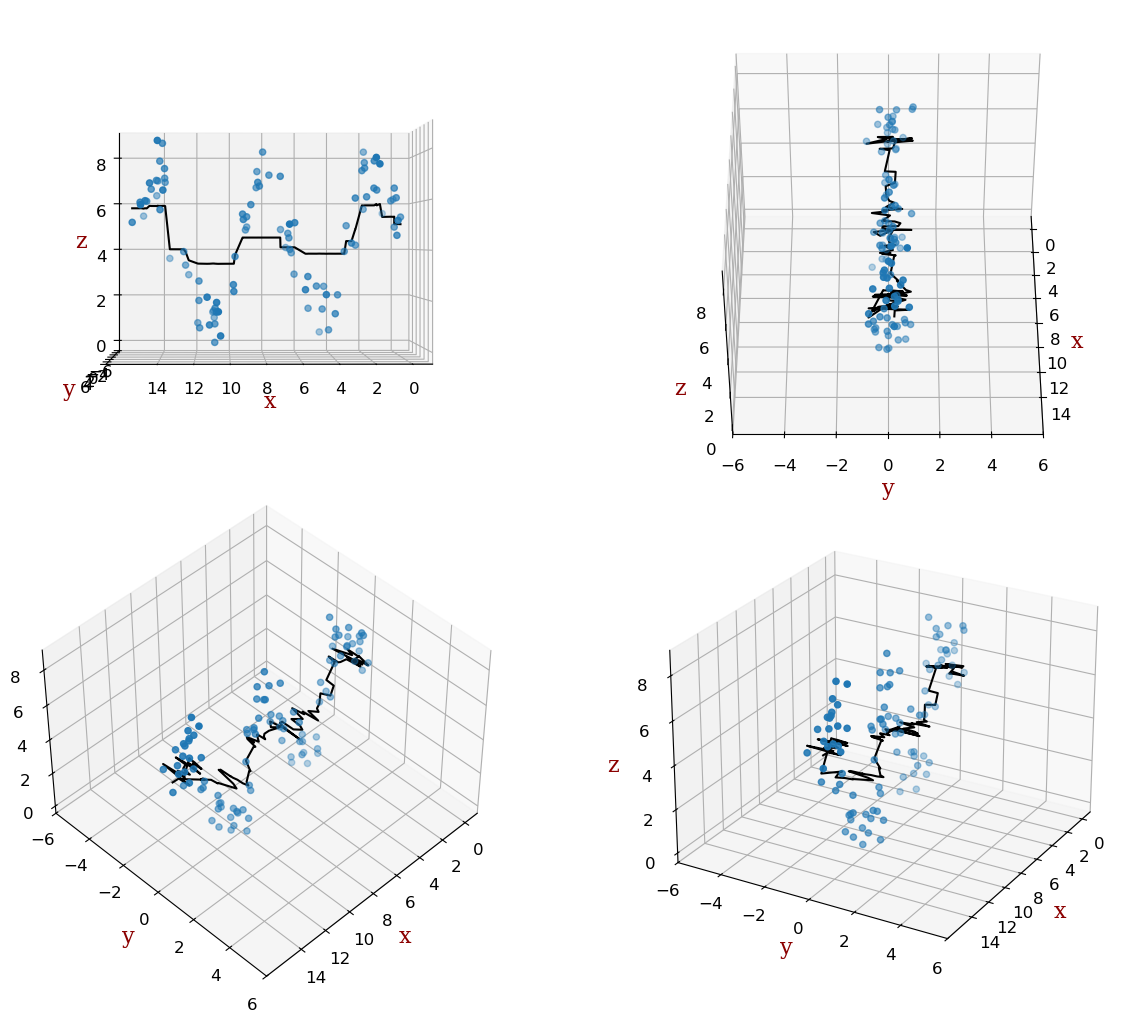

In [74]:
gb_fit_z = final_gb_reg.predict(X_train)
X_train_sort = X_train[X_train[:,0].argsort()]
gb_fit_z = gb_fit_z[X_train[:,0].argsort()]
plotscatter3Ddata(X_train_sort[:,0], X_train_sort[:,1], gb_fit_z, X_train[:,0], X_train[:,1], z_train)

### Optimal RandomForestRegressor Model

In [76]:
final_rf_reg = RandomForestRegressor(random_state = 42, min_samples_split=3 , max_depth=11, n_estimators=150)
final_rf_reg.fit(X_train, z_train)

RandomForestRegressor(max_depth=11, min_samples_split=3, n_estimators=150,
                      random_state=42)

### Plot Model Predictions for Training Set

Used the `plotscatter3Ddata(fit_x, fit_y, fit_z, scat_x, scat_y, scat_z)` function to plot the data and the prediction curve.

Saving figure Plot 1


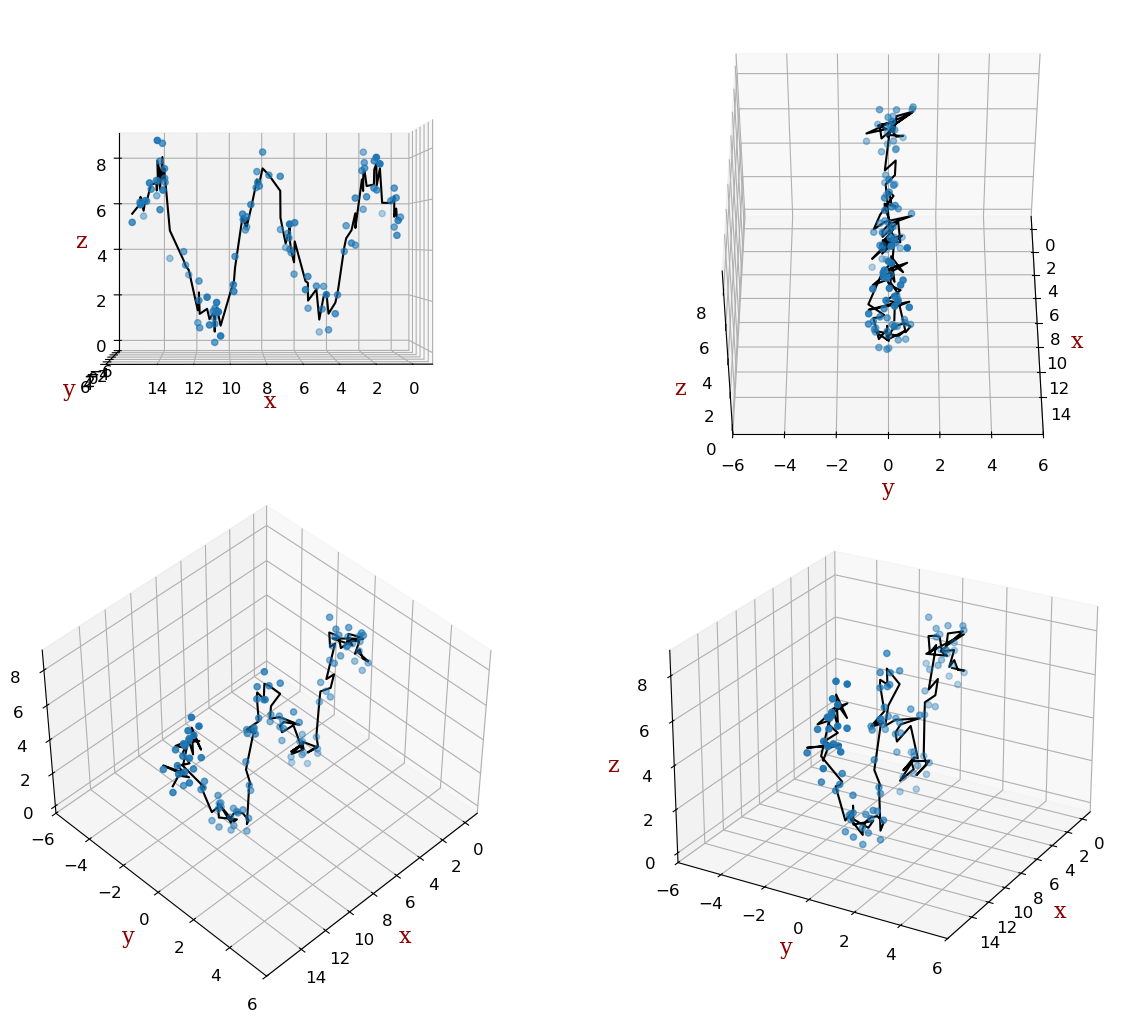

In [78]:
rf_fit_z = final_rf_reg.predict(X_train)
X_train_sort = X_train[X_train[:,0].argsort()]
rf_fit_z = rf_fit_z[X_train[:,0].argsort()]
plotscatter3Ddata(X_train_sort[:,0], X_train_sort[:,1], rf_fit_z, X_train[:,0], X_train[:,1], z_train)

### Optimal DecisionTreeRegressor Model

In [80]:
refined_dt_reg = DecisionTreeRegressor(random_state = 42, min_samples_split=5 , max_depth=14, splitter='best')
refined_dt_reg.fit(X_train, z_train)

DecisionTreeRegressor(max_depth=14, min_samples_split=5, random_state=42)

### Plot Model Predictions for Training Set

Used the `plotscatter3Ddata(fit_x, fit_y, fit_z, scat_x, scat_y, scat_z)` function to plot the data and the prediction curve.

Saving figure Plot 1


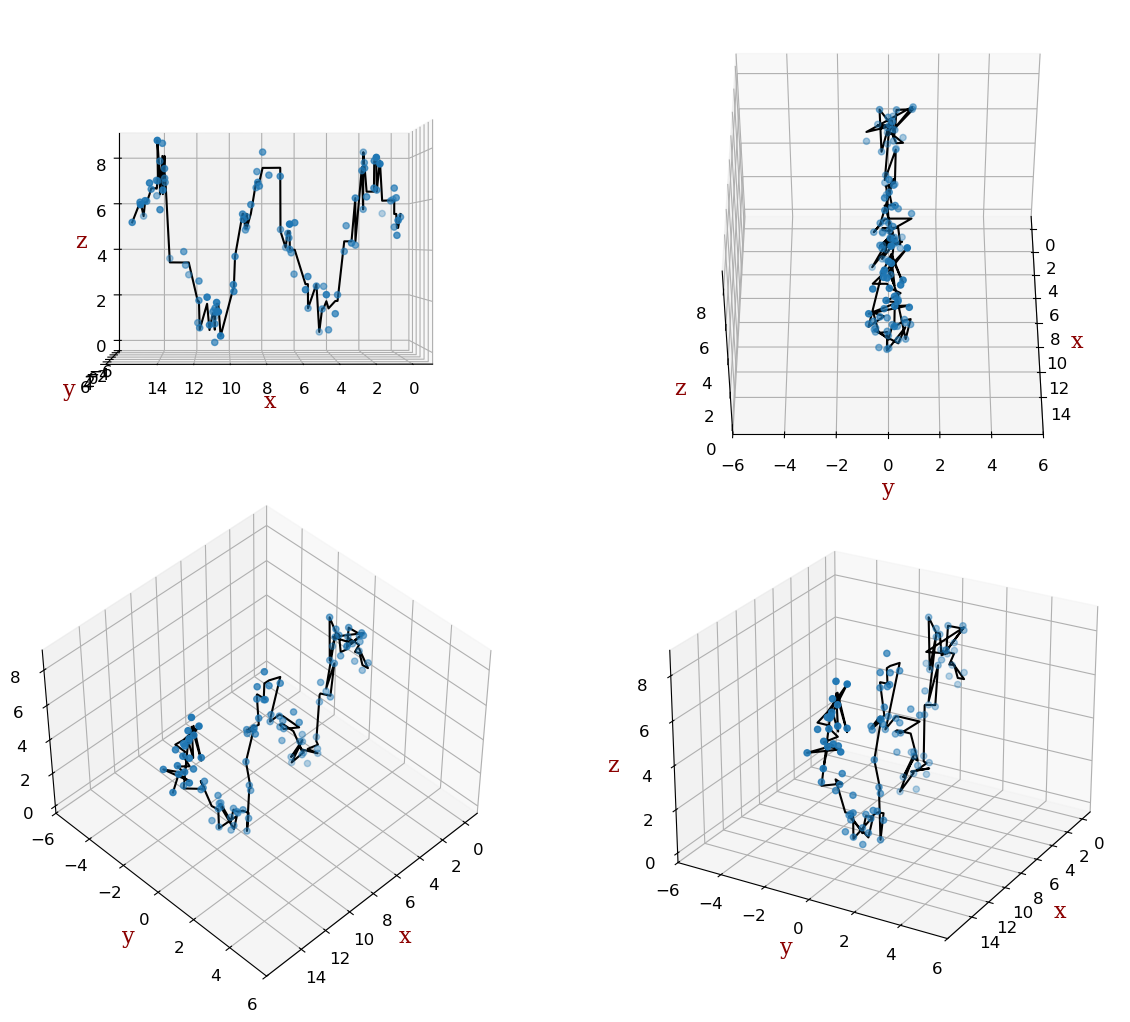

In [82]:
dt_fit_z = refined_dt_reg.predict(X_train)
X_train_sort = X_train[X_train[:,0].argsort()]
dt_fit_z = dt_fit_z[X_train[:,0].argsort()]
plotscatter3Ddata(X_train_sort[:,0], X_train_sort[:,1], dt_fit_z, X_train[:,0], X_train[:,1], z_train)

# Generalization Error

Computed the generalization error for each of the optimal models above.  Used MSE as the generalization error metric, rounding each output to four decimal places.  

In [84]:
from sklearn.metrics import mean_squared_error
final_gb_reg.fit(X_test, z_test)
gb_pred = final_gb_reg.predict(X_test)  
gb_mse = round(mean_squared_error(z_test, gb_pred),4)

In [85]:
final_rf_reg.fit(X_test, z_test)
rf_pred = final_rf_reg.predict(X_test)  
rf_mse = round(mean_squared_error(z_test, rf_pred),4)

In [86]:
refined_dt_reg.fit(X_test, z_test)
dt_pred = refined_dt_reg.predict(X_test)  
dt_mse = round(mean_squared_error(z_test, dt_pred),4)

In [87]:
# Printed the generalization error for all three models.
print("Gradient Boosting MSE ", gb_mse)
print("Random Forest MSE ", rf_mse)
print("Decision Tree MSE ", dt_mse)

Gradient Boosting MSE  2.052
Random Forest MSE  0.4437
Decision Tree MSE  0.395
